# Rotation evolution from analysis results

`/mnt6tb/data/analysis_results` から指定した `frame_ids` の分光解析・等時線解析結果を読み込み、恒星の自転速度進化を階層ベイズ推定する。各測定値には posterior mean、各誤差には posterior standard deviation を用いる。

In [1]:
from dataclasses import dataclass
from pathlib import Path

import arviz as az
import corner
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

jax.config.update("jax_enable_x64", True)

## Data container and result loader

The expected directory layout is

```
analysis_results/<date>/<object>/<frame_id>/orders03-08/mcmc.nc
analysis_results/<date>/<object>/<frame_id>/mistfit_g_st38/mcmc.nc
```

Frame IDs are normalized to eight digits. The requested order is preserved, and missing or duplicated results raise an explicit error.

In [2]:
ANALYSIS_ROOT = Path("/mnt6tb/data/analysis_results")
SPEC_LABEL = "orders03-08"
ISO_LABEL = "mistfit_g_st38"


def normalize_frame_id(value):
    value = str(value).strip().removeprefix("GRA").removeprefix("G")
    return value.zfill(8) if value.isdigit() else value


def posterior_mean_std(nc_path, variable):
    """Return posterior mean and standard deviation over chains and draws."""
    idata = az.from_netcdf(nc_path)
    if variable not in idata.posterior:
        raise KeyError(f"{variable!r} is absent from {nc_path}")
    values = np.asarray(idata.posterior[variable], dtype=float)
    mean = float(np.mean(values))
    std = float(np.std(values))
    if not np.isfinite(mean) or not np.isfinite(std) or std <= 0:
        raise ValueError(f"Invalid posterior mean/std for {variable!r} in {nc_path}")
    return mean, std


def find_frame_dir(root, frame_id):
    matches = sorted(p for p in root.rglob(frame_id) if p.is_dir())
    if not matches:
        raise FileNotFoundError(f"frame_id={frame_id} was not found below {root}")
    if len(matches) > 1:
        detail = "\n".join(map(str, matches))
        raise ValueError(f"frame_id={frame_id} is not unique below {root}:\n{detail}")
    return matches[0]


def result_path(frame_dir, label):
    path = frame_dir / label / "mcmc.nc"
    if not path.is_file():
        raise FileNotFoundError(f"Missing result: {path}")
    return path


@dataclass(frozen=True)
class RotEvol:
    frame_id: np.ndarray
    vsini: np.ndarray
    vsini_err: np.ndarray
    age: np.ndarray
    age_err: np.ndarray
    mass: np.ndarray
    mass_err: np.ndarray
    feh: np.ndarray
    feh_err: np.ndarray

    def __post_init__(self):
        names = ("vsini", "vsini_err", "age", "age_err", "mass", "mass_err", "feh", "feh_err")
        frame_id = np.asarray(self.frame_id, dtype=str)
        arrays = {name: np.asarray(getattr(self, name), dtype=float) for name in names}
        if frame_id.ndim != 1 or frame_id.size == 0:
            raise ValueError("frame_id must be a non-empty one-dimensional array")
        if len(set(frame_id)) != frame_id.size:
            raise ValueError("frame_id contains duplicates")
        if any(x.ndim != 1 or x.size != frame_id.size for x in arrays.values()):
            raise ValueError("All parameter arrays must be one-dimensional and match frame_id")
        if any(not np.all(np.isfinite(x)) for x in arrays.values()):
            raise ValueError("All parameter arrays must be finite")
        if any(np.any(arrays[name] <= 0) for name in ("vsini_err", "age_err", "mass_err", "feh_err")):
            raise ValueError("All standard deviations must be positive")
        if np.any(arrays["age"] <= 0) or np.any(arrays["mass"] <= 0):
            raise ValueError("age and mass must be positive")
        object.__setattr__(self, "frame_id", frame_id)
        for name, value in arrays.items():
            object.__setattr__(self, name, value)

    @property
    def N(self):
        return self.frame_id.size

    @classmethod
    def from_analysis_results(cls, frame_ids, root=ANALYSIS_ROOT, spec_label=SPEC_LABEL, iso_label=ISO_LABEL):
        root = Path(root)
        if not root.is_dir():
            raise FileNotFoundError(f"Analysis root is not mounted or does not exist: {root}")
        normalized = [normalize_frame_id(x) for x in frame_ids]
        if not normalized:
            raise ValueError("frame_ids must not be empty")
        if len(set(normalized)) != len(normalized):
            raise ValueError("frame_ids contains duplicates after normalization")

        rows = []
        for frame_id in normalized:
            frame_dir = find_frame_dir(root, frame_id)
            spec_nc = result_path(frame_dir, spec_label)
            iso_nc = result_path(frame_dir, iso_label)
            vsini, vsini_err = posterior_mean_std(spec_nc, "vsini")
            feh, feh_err = posterior_mean_std(spec_nc, "feh")
            age, age_err = posterior_mean_std(iso_nc, "age")
            mass, mass_err = posterior_mean_std(iso_nc, "mass")
            rows.append((frame_id, vsini, vsini_err, age, age_err, mass, mass_err, feh, feh_err))

        columns = list(zip(*rows))
        return cls(columns[0], *columns[1:])

## NumPyro model

Age is in Gyr. The equatorial velocity follows

$$\log_{10}v = a\log_{10}(t/1\,\mathrm{Gyr}) + b.$$

True ages are latent and constrained by their measured means and standard deviations. Isotropic spin axes imply $\cos i\sim\mathrm{Uniform}(0,1)$. `mass` and `feh` are retained in `RotEvol` for future extensions but are not yet used in the rotation law.

In [3]:
def linear_model(age_gyr, a, b):
    return a * jnp.log10(age_gyr) + b


def numpyro_model(re):
    a = numpyro.sample("a", dist.Normal(-0.5, 0.5))
    b = numpyro.sample("b", dist.Normal(1.0, 1.0))

    with numpyro.plate("stars", re.N):
        age = numpyro.sample("age", dist.Uniform(0.01, 13.8))
        numpyro.sample("age_obs", dist.Normal(age, jnp.asarray(re.age_err)), obs=jnp.asarray(re.age))
        cosi = numpyro.sample("cosi", dist.Uniform(0.0, 1.0))
        velocity = numpyro.deterministic("velocity", 10.0 ** linear_model(age, a, b))
        vsini_model = numpyro.deterministic("vsini_model", velocity * jnp.sqrt(1.0 - cosi**2))
        numpyro.sample("vsini_obs", dist.Normal(vsini_model, jnp.asarray(re.vsini_err)), obs=jnp.asarray(re.vsini))

## Select frames and load data

Edit `FRAME_IDS`. Loading is skipped while the list is empty, so the notebook remains executable on machines where the data volume is not mounted.

In [4]:
FRAME_IDS = [
    "00029409", "00029410", "00029411", "00029412", "00029413", "00029414", "00029415", "00029416",
]

re = None
if FRAME_IDS:
    re = RotEvol.from_analysis_results(FRAME_IDS)
    print(f"Loaded {re.N} stars:", re.frame_id.tolist())
else:
    print("Set FRAME_IDS to load analysis results.")

Loaded 8 stars: ['00029409', '00029410', '00029411', '00029412', '00029413', '00029414', '00029415', '00029416']


## Run inference

Sampling is performed only after data have been loaded.

In [5]:
mcmc = None
if re is not None:
    kernel = NUTS(numpyro_model, target_accept_prob=0.9)
    mcmc = MCMC(kernel, num_warmup=500, num_samples=1000, num_chains=2, chain_method="sequential")
    mcmc.run(jax.random.PRNGKey(0), re)
    mcmc.print_summary(exclude_deterministic=False)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


  0%|          | 0/1500 [00:00<?, ?it/s]

warmup:   0%|          | 1/1500 [00:02<55:16,  2.21s/it, 1 steps of size 1.95e+00. acc. prob=0.00]

warmup:   5%|▍         | 73/1500 [00:02<00:32, 44.06it/s, 1023 steps of size 3.40e-03. acc. prob=0.85]

warmup:   9%|▉         | 142/1500 [00:02<00:14, 95.45it/s, 511 steps of size 1.44e-02. acc. prob=0.87]

...

sample:  80%|███████▉  | 1196/1500 [00:02<00:00, 1117.07it/s, 255 steps of size 1.40e-02. acc. prob=0.96]

sample:  89%|████████▉ | 1333/1500 [00:02<00:00, 1171.24it/s, 511 steps of size 1.40e-02. acc. prob=0.96]

sample:  98%|█████████▊| 1474/1500 [00:03<00:00, 1233.36it/s, 511 steps of size 1.40e-02. acc. prob=0.96]

sample: 100%|██████████| 1500/1500 [00:03<00:00, 492.45it/s, 255 steps of size 1.40e-02. acc. prob=0.96] 


                    mean       std    median      5.0%     95.0%     n_eff     r_hat
             a     -1.47      0.37     -1.51     -2.03     -0.83    655.46      1.00
        age[0]      2.76      0.40      2.76      2.10      3.39   1445.38      1.00
        age[1]      3.11      0.76      3.18      1.89      4.36   1526.80      1.00
        age[2]      2.13      0.22      2.12      1.74      2.46   1247.26      1.00
        age[3]      8.60      2.31      8.64      4.62     12.26   1562.51      1.00
        age[4]      1.41      0.27      1.43      0.99      1.85    862.40      1.00
        age[5]      6.09      1.20      6.08      4.13      8.06   1850.50      1.00
        age[6]      2.00      0.25      2.01      1.58      2.40   1315.95      1.00
        age[7]      1.80      0.26      1.81      1.40      2.22    917.51      1.00
             b      1.84      0.14      1.83      1.60      2.05    734.92      1.00
       cosi[0]      0.96      0.04      0.97      0.92      0.99

## Posterior plots

The corner plot shows the joint posterior of the power-law parameters. The age--$v\sin i$ panel displays the measurements with both uncertainties on logarithmic axes. The overlaid power law is the inferred equatorial velocity relation $v=10^b(t/\mathrm{Gyr})^a$; individual $v\sin i$ measurements generally lie below it because of inclination.

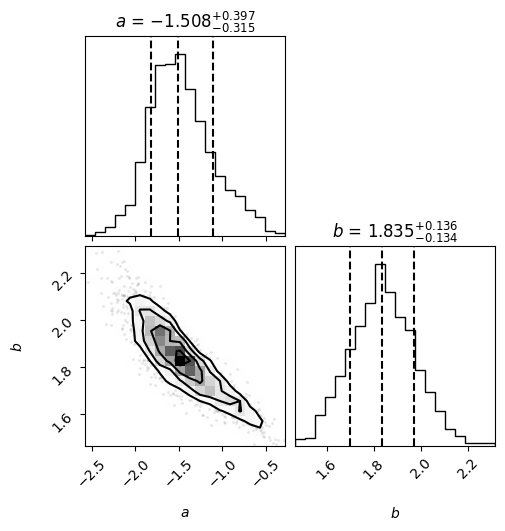

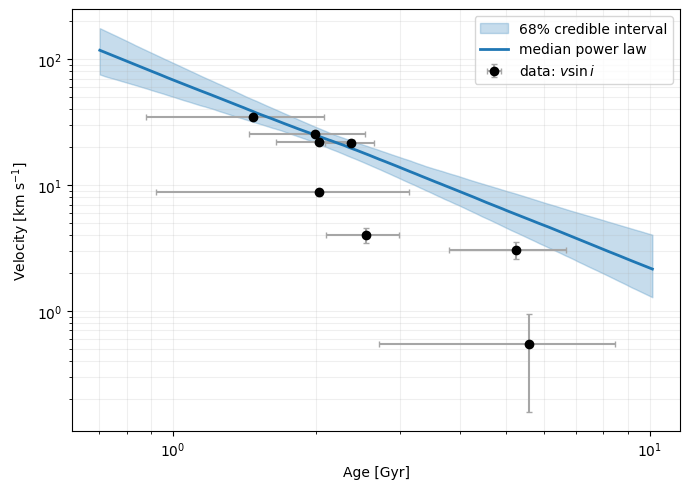

In [6]:
if mcmc is not None:
    samples = mcmc.get_samples()
    ab_samples = np.column_stack([np.asarray(samples["a"]), np.asarray(samples["b"])])

    corner.corner(
        ab_samples,
        labels=[r"$a$", r"$b$"],
        show_titles=True,
        title_fmt=".3f",
        quantiles=[0.16, 0.5, 0.84],
    )
    plt.show()

    age_grid = np.geomspace(
        max(0.01, np.min(re.age - re.age_err) * 0.8),
        min(13.8, np.max(re.age + re.age_err) * 1.2),
        300,
    )
    model_draws = (
        10.0 ** np.asarray(samples["b"])[:, None]
        * age_grid[None, :] ** np.asarray(samples["a"])[:, None]
    )
    model_q16, model_q50, model_q84 = np.percentile(model_draws, [16, 50, 84], axis=0)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.errorbar(
        re.age, re.vsini,
        xerr=re.age_err, yerr=re.vsini_err,
        fmt="o", color="black", ecolor="0.65", capsize=2,
        label=r"data: $v\sin i$",
    )
    ax.fill_between(
        age_grid, model_q16, model_q84,
        color="C0", alpha=0.25, label="68% credible interval",
    )
    ax.plot(age_grid, model_q50, color="C0", lw=2, label="median power law")
    ax.set(
        xscale="log", yscale="log",
        xlabel="Age [Gyr]", ylabel=r"Velocity [km s$^{-1}$]",
    )
    ax.grid(which="both", alpha=0.2)
    ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print("Load FRAME_IDS and run inference to create posterior plots.")

## Interface smoke test

This test uses a tiny in-memory dataset. It verifies array validation and that `numpyro_model(re)` can be evaluated without requiring the external data mount.

In [7]:
from numpyro.handlers import seed, trace

test_re = RotEvol(
    frame_id=["00000001", "00000002"],
    vsini=[8.0, 4.0], vsini_err=[0.5, 0.4],
    age=[1.0, 4.5], age_err=[0.1, 0.3],
    mass=[1.05, 0.95], mass_err=[0.03, 0.04],
    feh=[0.0, -0.1], feh_err=[0.05, 0.06],
)
model_trace = trace(seed(numpyro_model, jax.random.PRNGKey(1))).get_trace(test_re)
assert test_re.N == 2
assert np.shape(model_trace["vsini_model"]["value"]) == (2,)
print("RotEvol and numpyro_model smoke test passed.")

RotEvol and numpyro_model smoke test passed.
